In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
read= pd.read_csv('Students Social Media Addiction.csv')
df = pd.DataFrame(read)
display(df.head())

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


In [23]:
print("Missing values:\n", df.isnull().sum())
print("\nNumber of duplicates:", df.duplicated().sum())
print("\nData types:\n", df.dtypes)

Missing values:
 Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Relationship_Status             0
Conflicts_Over_Social_Media     0
Addicted_Score                  0
Risk_Level                      0
Detox_Strategy                  0
dtype: int64

Number of duplicates: 0

Data types:
 Student_ID                        int64
Age                               int64
Gender                           object
Academic_Level                   object
Country                          object
Avg_Daily_Usage_Hours           float64
Most_Used_Platform               object
Affects_Academic_Performance     object
Sleep_Hours_Per_Night           float64
Mental_Health_Score               int64
Relationship_Status  

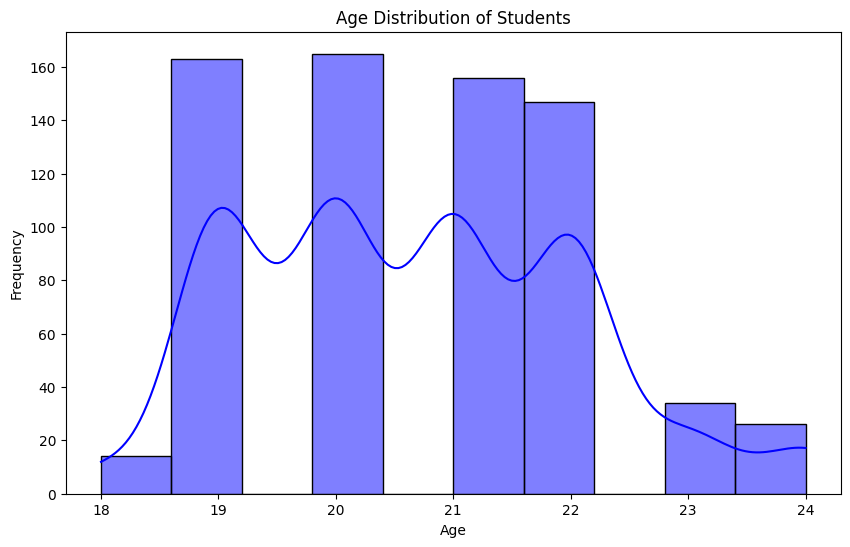

In [13]:
#Showcasing age distribution of students with Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=10, kde=True, color='blue')
plt.title('Age Distribution of Students')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

**Insight: The histogram shows a relatively even distribution of student ages in the dataset, with a slight peak around 19-20 years old.**

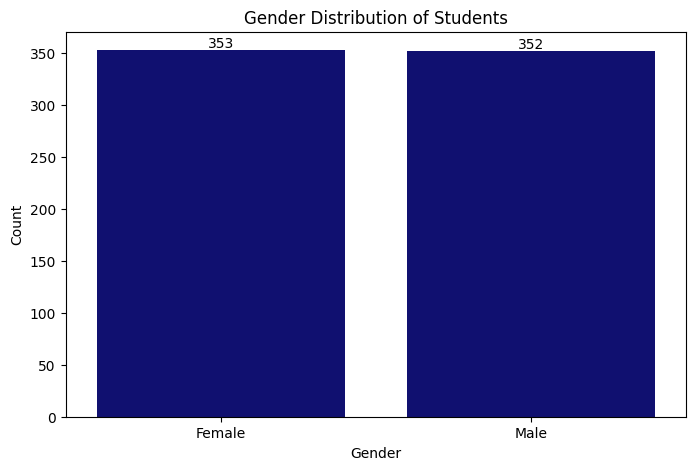

In [42]:
#Showcasing gender distribution of students with countplot
plt.figure(figsize=(8, 5))
plot = sns.countplot(x='Gender', data=df, color='navy')
plt.title('Gender Distribution of Students')
plt.xlabel('Gender')
plt.ylabel('Count')

# This loop adds data labels to each bar
for container in plot.containers:
    plot.bar_label(container)
plt.show()

**Insight: The countplot reveals a balanced representation of genders among the students surveyed.**

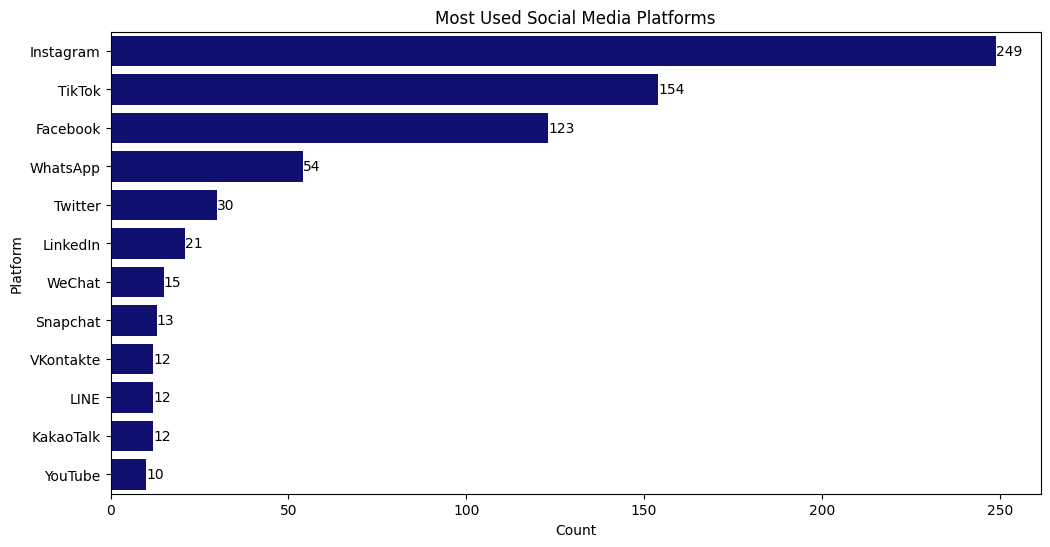

In [30]:
#Showcasing most used social media platforms with countplot
plt.figure(figsize=(12, 6))
plot = sns.countplot(y='Most_Used_Platform', data=df, order = df['Most_Used_Platform'].value_counts().index, color='navy')
plt.title('Most Used Social Media Platforms')
plt.xlabel('Count')
plt.ylabel('Platform')

# This loop adds data labels to each bar
for container in plot.containers:
    plot.bar_label(container)
plt.show()

**Insight: Instagram and TikTok are the most frequently used social media platforms among the students in this study.**

Average Addiction Score by Gender:


,Gender,Addicted_Score
0,Female,6.515581
1,Male,6.357955


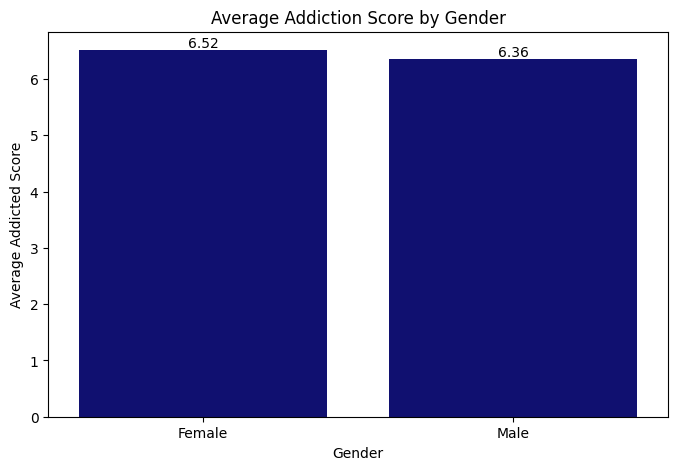

In [31]:
#Group by gender
gender_addiction = df.groupby('Gender')['Addicted_Score'].mean().reset_index()
print("Average Addiction Score by Gender:")
display(gender_addiction)

#Showcasing average addiction score by gender with barplot
plt.figure(figsize=(8, 5))
plot = sns.barplot(x='Gender', y='Addicted_Score', data=gender_addiction, color='navy')
plt.title('Average Addiction Score by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Addicted Score')

# This loop adds data labels to each bar
for container in plot.containers:
    plot.bar_label(container, fmt='%.2f')
plt.show()

**Insight: Female students, on average, have a slightly higher social media addiction score compared to male students.**

Average Addiction Score by Age:


,Age,Addicted_Score
0,18,7.785714
1,19,6.650307
2,20,6.478788
3,21,6.589744
4,22,6.095238
5,23,5.676471
6,24,6.115385


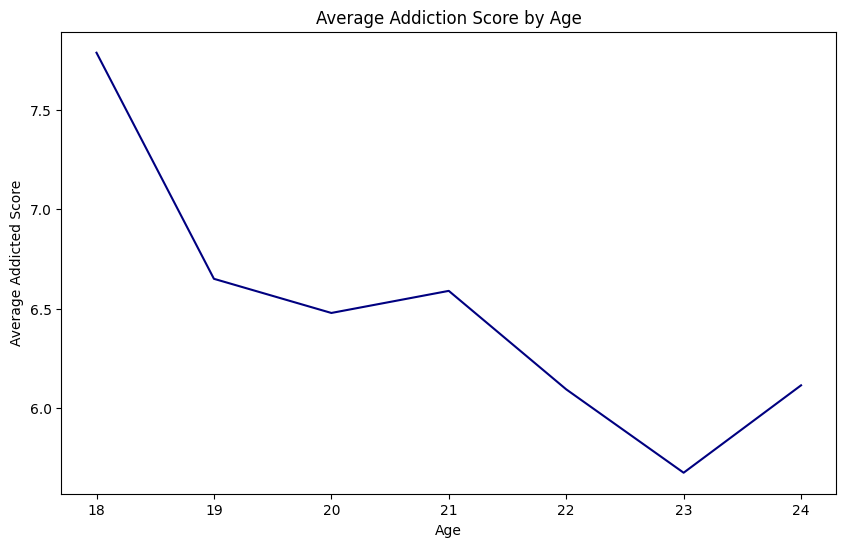

In [17]:
#Group by age
age_addiction = df.groupby('Age')['Addicted_Score'].mean().reset_index()
print("Average Addiction Score by Age:")
display(age_addiction)

plt.figure(figsize=(10, 6))
sns.lineplot(x='Age', y='Addicted_Score', data=age_addiction, color='navy')
plt.title('Average Addiction Score by Age')
plt.xlabel('Age')
plt.ylabel('Average Addicted Score')
plt.show()

**Insight: The average addiction score tends to decrease as student age increases, suggesting older students might have better self-regulation.**

Average Addiction Score by Education Level:


,Academic_Level,Addicted_Score
0,Graduate,6.243077
1,High School,8.037037
2,Undergraduate,6.492918


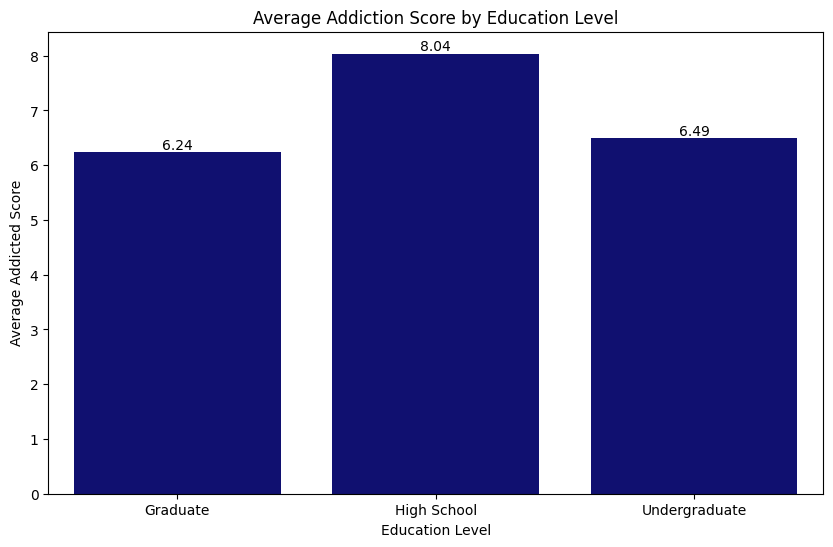

In [32]:
#Group by academic level
education_addiction = df.groupby('Academic_Level')['Addicted_Score'].mean().reset_index()
print("Average Addiction Score by Education Level:")
display(education_addiction)

plt.figure(figsize=(10, 6))
plot = sns.barplot(x='Academic_Level', y='Addicted_Score', data=education_addiction, color='navy')
plt.title('Average Addiction Score by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Average Addicted Score')

# This loop adds data labels to each bar
for container in plot.containers:
    plot.bar_label(container, fmt='%.2f')
plt.show()

**Insight: High school students show the highest average social media addiction scores compared to undergraduate and graduate students.**

Average Addiction Score by Academic Performance:


,Affects_Academic_Performance,Addicted_Score
0,No,4.595238
1,Yes,7.461369


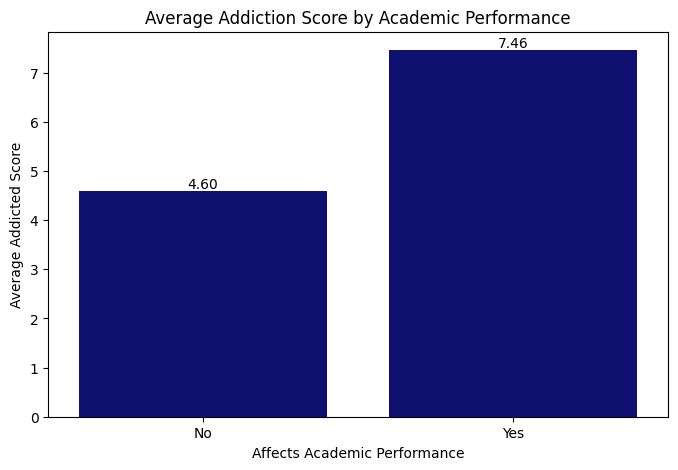

In [33]:
#Group by affcts academic performance
academic_addiction = df.groupby('Affects_Academic_Performance')['Addicted_Score'].mean().reset_index()
print("Average Addiction Score by Academic Performance:")
display(academic_addiction)

plt.figure(figsize=(8, 5))
plot = sns.barplot(x='Affects_Academic_Performance', y='Addicted_Score', data=academic_addiction, color='navy')
plt.title('Average Addiction Score by Academic Performance')
plt.xlabel('Affects Academic Performance')
plt.ylabel('Average Addicted Score')

# This loop adds data labels to each bar
for container in plot.containers:
    plot.bar_label(container, fmt='%.2f')
plt.show()

**Insight: Students who report that social media affects their academic performance have significantly higher addiction scores.**

In [20]:
def classify_risk_level(addiction_score):
    if addiction_score >= 8:
        return 'High Risk'
    elif addiction_score >= 5:
        return 'Medium Risk'
    else:
        return 'Low Risk'

def suggest_detox_strategy(risk_level):
    if risk_level == 'High Risk':
        return 'Seek professional help and consider a digital detox program.'
    elif risk_level == 'Medium Risk':
        return 'Limit daily usage and explore mindful social media habits.'
    else:
        return 'Maintain healthy usage habits and be mindful of screen time.'

# Apply the functions to the DataFrame
df['Risk_Level'] = df['Addicted_Score'].apply(classify_risk_level)
df['Detox_Strategy'] = df['Risk_Level'].apply(suggest_detox_strategy)

display(df[['Addicted_Score', 'Risk_Level', 'Detox_Strategy']].head())

,Addicted_Score,Risk_Level,Detox_Strategy
0,8,High Risk,Seek professional help and consider a digital ...
1,3,Low Risk,Maintain healthy usage habits and be mindful o...
2,9,High Risk,Seek professional help and consider a digital ...
3,4,Low Risk,Maintain healthy usage habits and be mindful o...
4,7,Medium Risk,Limit daily usage and explore mindful social m...


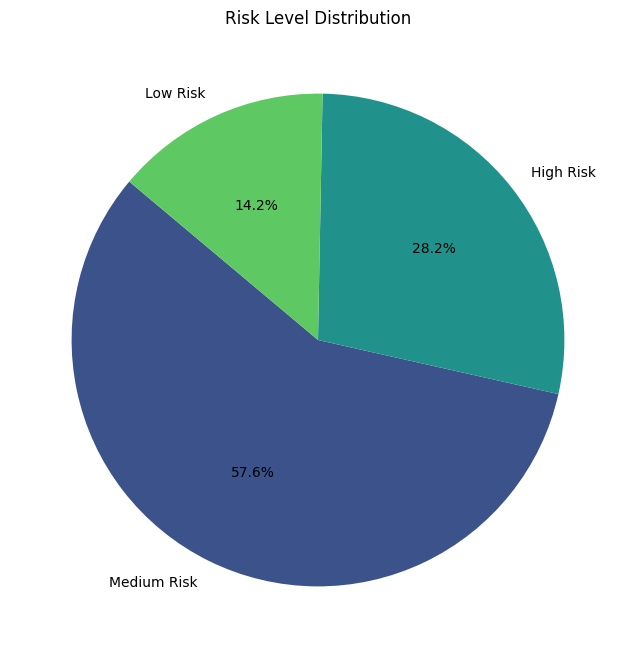

In [40]:
#Counting risk level
risk_level_counts = df['Risk_Level'].value_counts()

#Showcasing Risk level distribution with pie chart
plt.figure(figsize=(8, 8))
plt.pie(risk_level_counts, labels=risk_level_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', len(risk_level_counts)))
plt.title('Risk Level Distribution')
plt.show()

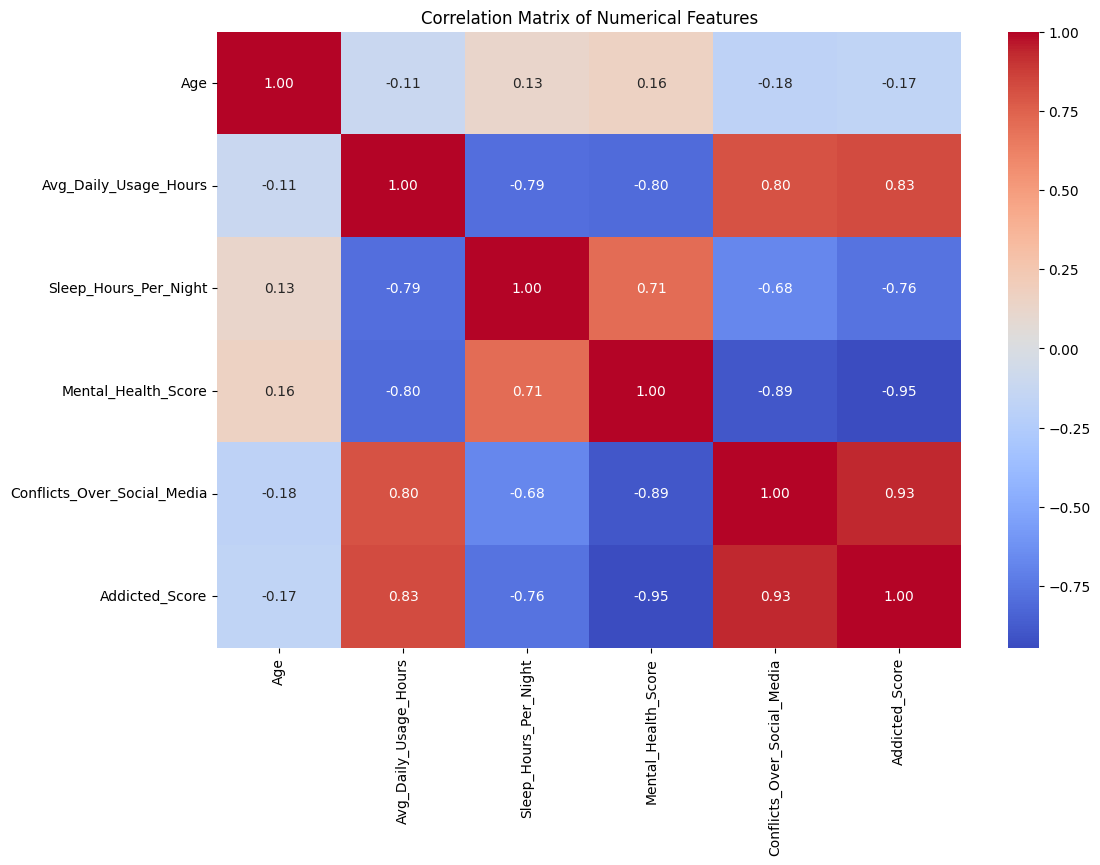

In [21]:
#Showcasing correlation matrix of numerical variables with heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df[['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Conflicts_Over_Social_Media', 'Addicted_Score']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

**Insight: The correlation matrix highlights a strong positive relationship between daily usage hours, conflicts over social media, and addiction score, while negatively correlating with sleep hours and mental health score.**

**The Unseen Battle: A Story of Student Social Media Addiction**

The data reveals a silent struggle among students, with social media addiction casting a long shadow over their well-being. I discovered that higher average daily usage is strongly linked to a higher addiction score, with a staggering number of students spending over 5 hours a day on various platforms. This excessive use, particularly on visually-driven platforms like Instagram and TikTok, directly correlates with poorer mental health scores and increased conflicts in relationships.

High school students show the highest average social media addiction scores compared to undergraduate and graduate students.

The most alarming finding is the strong negative correlation between addiction scores and sleep, with many addicted students getting less than 6 hours of sleep per night. This sleep damage, in turn, severely affects their academic performance, creating a vicious cycle of stress and dependency.

Our analysis shows that students who report that social media affects their academic performance have a significantly higher addiction score. We've also classified students into risk levels, with a significant portion falling into the "High Risk" category, requiring immediate intervention.

Therefore, we recommend targeted awareness campaigns focusing on the importance of digital well-being, promoting mindful social media usage, and providing resources for students to seek professional help. Our custom-developed detox strategies can serve as a first step in guiding students towards a healthier relationship with social media, ultimately fostering a more balanced and productive student life.